## Synthesize event stream 

### Steps

1. **Create BPMN File** — Use [bpmn.io](https://bpmn.io) to design and export your BPMN process model.

2. **Simulate Process Executions** — Use [BIMP](https://bimp.cs.ut.ee/simulator) to simulate process executions and export the results in `.mxml.gz` format. Unzip the file using [7-Zip](https://www.7-zip.org).

3. **Filter Event Log** — Use the *Simple Heuristics* filter in [ProM](https://www.promtools.org) to remove artificial start and end events. Save the filtered log as `.xes`.

4. **Combine Logs** *(optional)* — Merge with additional logs if needed, for example to simulate **concept drift** by switching between different process models.

In [43]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import pandas as pd
import pm4py


def reassign_uniform_arrivals(
    log: pd.DataFrame,
    case_arrival_rate_minutes: int,
    start_time: datetime,
    case_prefix: str = '',
) -> pd.DataFrame:
    """
    Reassigns timestamps so that cases arrive uniformly spaced.
    Intra-case relative timings (task durations, order) are preserved.
    """
    log = log.copy()
    log['time:timestamp'] = pd.to_datetime(log['time:timestamp']).dt.tz_localize(None)

    # Sort cases by their original start time to preserve natural order
    case_starts = log.groupby('case:concept:name')['time:timestamp'].min().sort_values()

    new_rows = []
    for i, (case_id, _) in enumerate(case_starts.items()):
        case_events = log[log['case:concept:name'] == case_id].copy()
        case_events = case_events.sort_values('time:timestamp')

        original_start = case_events['time:timestamp'].min()
        new_start = start_time + timedelta(minutes=i * case_arrival_rate_minutes)
        offset = new_start - original_start

        case_events['time:timestamp'] = case_events['time:timestamp'] + offset

        if case_prefix:
            case_events['case:concept:name'] = case_prefix + case_events[
                'case:concept:name'
            ].astype(str)

        new_rows.append(case_events)

    return pd.concat(new_rows).sort_values('time:timestamp').reset_index(drop=True)


def show_active_cases(log, drift_time=None):
    case_spans = log.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    case_spans.columns = ['start', 'end']

    events = pd.concat(
        [
            pd.Series(1, index=case_spans['start']),
            pd.Series(-1, index=case_spans['end']),
        ]
    ).sort_index()

    active_cases = events.cumsum()

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.step(
        active_cases.index,
        active_cases.values,
        where='post',
        color='steelblue',
        linewidth=1.5,
    )
    if drift_time is not None:
        ax.axvline(
            drift_time, color='red', linestyle='--', linewidth=1.5, label='Concept drift'
        )
    ax.fill_between(
        active_cases.index,
        active_cases.values,
        step='post',
        alpha=0.15,
        color='steelblue',
    )

    ax.set_xlabel('Time')
    ax.set_ylabel('Active cases')
    ax.set_title('Number of active cases over time')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [39]:
LOG_A_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/before_drift.xes'
LOG_B_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/after_drift.xes'

LOG_RESULT_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/drift.xes'

case_arrival_rate = 20 # minutes
task_duration = 10 # minutes

In [57]:
log_a = pm4py.read_xes(LOG_A_PATH)
log_b = pm4py.read_xes(LOG_B_PATH)

stream_start = datetime(2024, 1, 1, 8, 0, 0)
n_cases_a = log_a['case:concept:name'].nunique()

log_a_uniform = reassign_uniform_arrivals(
    log_a, case_arrival_rate, stream_start, case_prefix='A_'
)

log_b_start = (
    log_a_uniform.groupby('case:concept:name')['time:timestamp'].max().quantile(0.50)
)
log_b_uniform = reassign_uniform_arrivals(
    log_b, case_arrival_rate, log_b_start, case_prefix='B_'
)

combined_log = pd.concat([log_a_uniform, log_b_uniform], ignore_index=True)

pm4py.write_xes(combined_log, LOG_RESULT_PATH)
print(
    f'Combined: {combined_log["case:concept:name"].nunique()} cases, {len(combined_log)} events'
)


Combined: 1000 cases, 34110 events


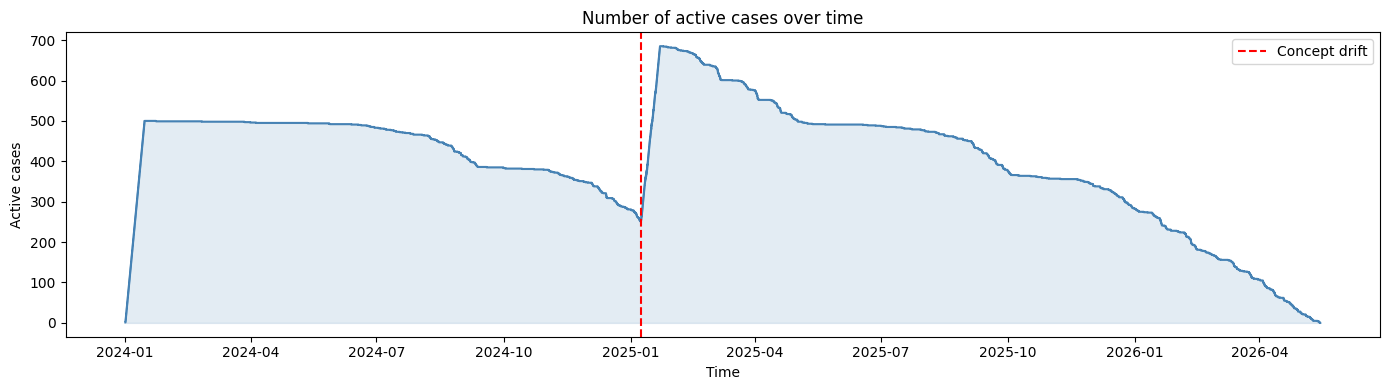

In [58]:
show_active_cases(combined_log, drift_time=log_b_uniform['time:timestamp'].min())

C:\Users\Pavel\AppData\Local\Temp\ipykernel_14056\2120223160.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


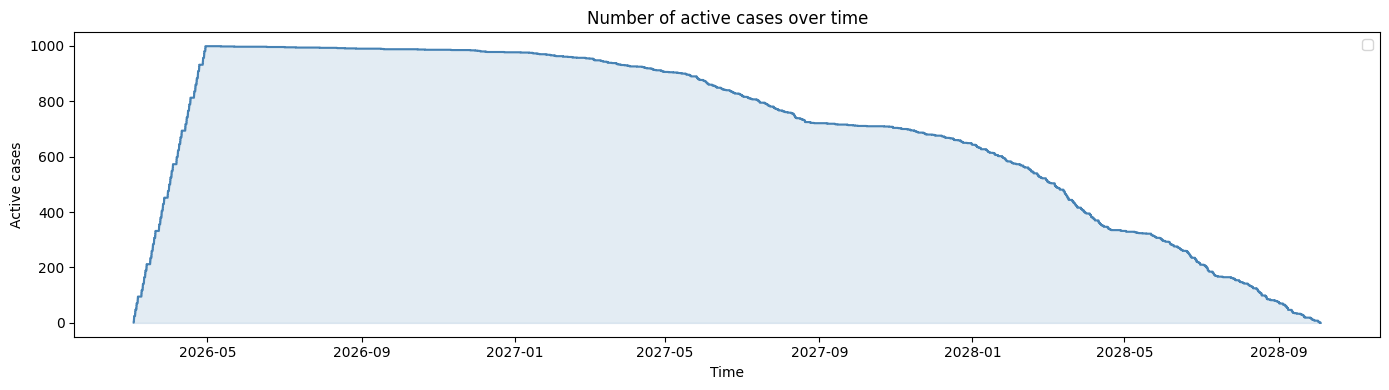

In [51]:
FULL_LOG_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/no_drift.xes'

NEW_FULL_LOG_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/no_drift_uniform.xes'

full_log = pm4py.read_xes(FULL_LOG_PATH)

show_active_cases(full_log)

C:\Users\Pavel\AppData\Local\Temp\ipykernel_14056\2120223160.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


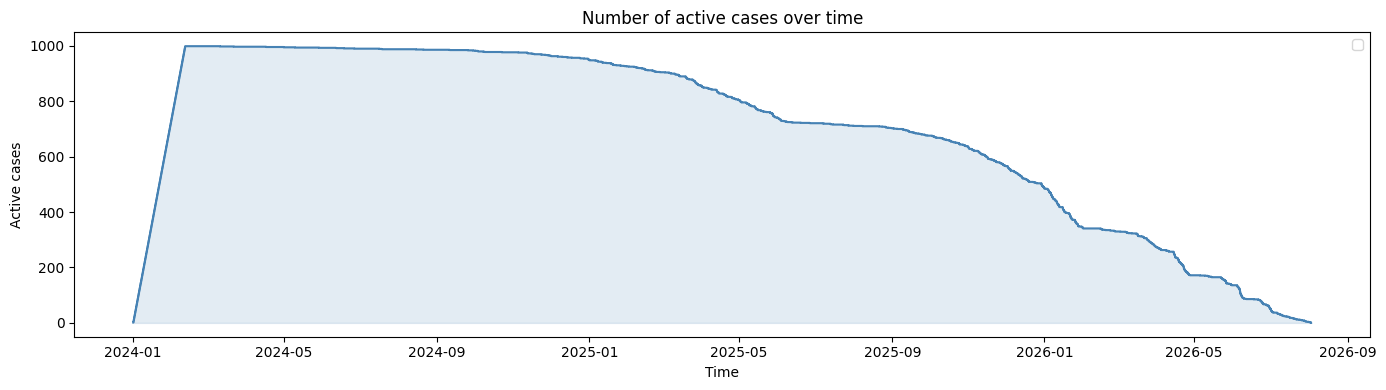

In [59]:
case_arrival_rate = 60 # minutes

full_log_uniform = reassign_uniform_arrivals(
    full_log, case_arrival_rate, stream_start, case_prefix=''
)

show_active_cases(full_log_uniform)

C:\Users\Pavel\AppData\Local\Temp\ipykernel_14056\2120223160.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


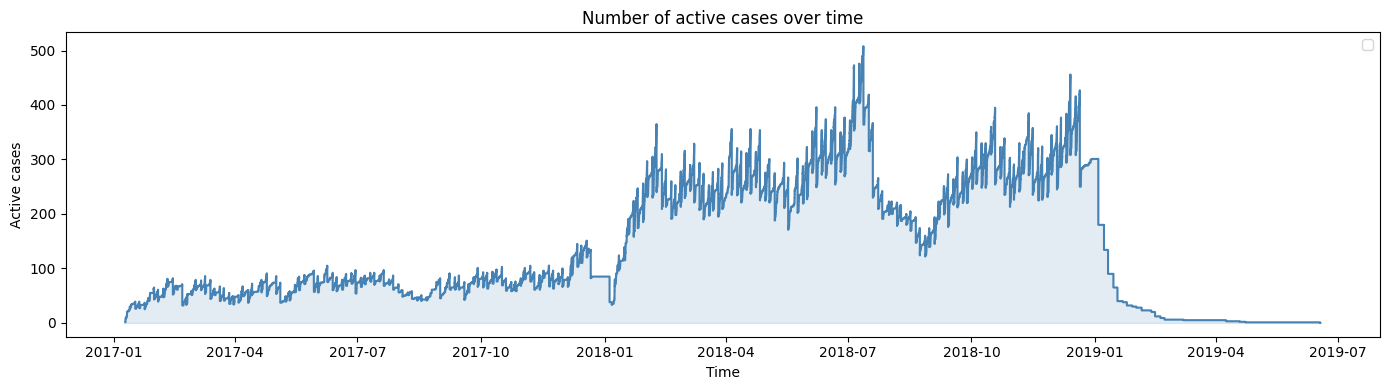

In [53]:
BPIC_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/BPIC_20_DD.xes'

bpic_log = pm4py.read_xes(BPIC_PATH)

show_active_cases(bpic_log)